In [1]:
import glob
import warnings

import cv2
import matplotlib.pyplot as plt
import tifffile

from bubbles.detect import DetectionParams, detect_bubbles, draw_overlay
import os

import numpy as np


def pix_to_world(xs, ys, rs,coord_file = '/mnt/d/Users/zl483/digiflow/trajectories/lid/bubbles_mapping.csv'):
    # pixel to world coordinates mapping
    # coord_name = 'april_bonus'
    quadratic_variables = ['1', 'x', 'x^2', 'y', 'y^2', 'xy', 'x^2*y', 'x*y^2']

    # read the mapping coefficients from the .csv
    # first row maps to world x, second row maps to world y
    # coord_file = f'/mnt/d/Users/zl483/highspeedcamera/{coord_name}_mapping.csv'
    mappingX = np.loadtxt(coord_file, delimiter=',', skiprows=0, max_rows=1)
    mappingY = np.loadtxt(coord_file, delimiter=',', skiprows=1, max_rows=1)

    xs = np.array(xs)
    ys = (ny - np.array(ys))
    rs = np.array(rs)

    XWorld = np.ones_like(xs) * mappingX[0] + \
                mappingX[1] * xs + \
                mappingX[2] * xs**2 + \
                mappingX[3] * ys + \
                mappingX[4] * ys**2 + \
                mappingX[5] * xs * ys + \
                mappingX[6] * xs**2 * ys + \
                mappingX[7] * xs * ys**2
    YWorld = np.ones_like(ys) * mappingY[0] + \
            mappingY[1] * xs + \
            mappingY[2] * xs**2 + \
            mappingY[3] * ys + \
            mappingY[4] * ys**2 + \
            mappingY[5] * xs * ys + \
            mappingY[6] * xs**2 * ys + \
            mappingY[7] * xs * ys**2

    # equivalent radius from area ratio
    area_per_pix = 7.711063816901217E-005
    RWorld = np.sqrt(area_per_pix) * rs

    return XWorld, YWorld, RWorld

In [2]:
# --- list all frames ---
test_no = 10

frames = sorted(glob.glob("temp/*.tif"))
print(f"{len(frames)} frames found")
frames[:5]

frames_to_process = frames[112::6]
bubble_dict = {}

rescale_factor = 0.0087812663

146 frames found


<tifffile.TiffPage 0 @8> missing data ByteCounts tag


temp/test_10_run_0145.tif
shape: (3072, 4096) dtype: uint8


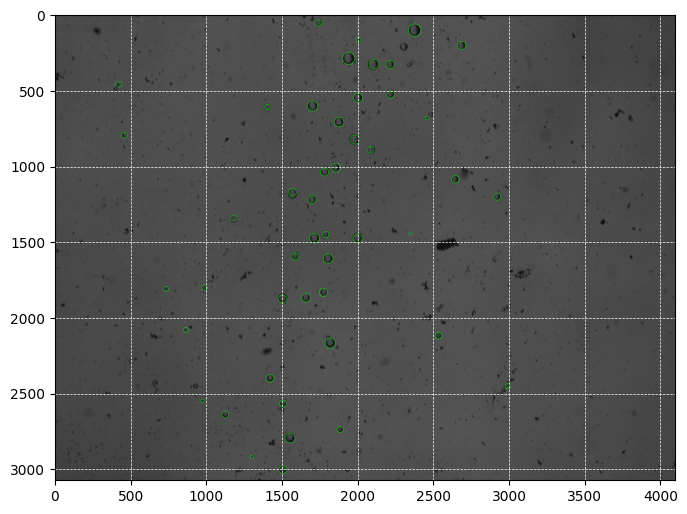

47 bubble(s) detected
  cx=2376  cy=100  r=41  hollowness=37.86  uniformity=0.30
  cx=2106  cy=324  r=31  hollowness=35.06  uniformity=0.39
  cx=1940  cy=286  r=40  hollowness=43.14  uniformity=0.28
  cx=1552  cy=2794  r=32  hollowness=38.18  uniformity=0.29
  cx=2000  cy=1476  r=29  hollowness=27.93  uniformity=0.66
  cx=1700  cy=600  r=34  hollowness=43.01  uniformity=0.30
  cx=1982  cy=822  r=30  hollowness=40.60  uniformity=0.20
  cx=1818  cy=2168  r=33  hollowness=37.45  uniformity=0.36
  cx=1876  cy=706  r=31  hollowness=50.78  uniformity=0.19
  cx=1698  cy=1218  r=27  hollowness=41.55  uniformity=0.33
  cx=1804  cy=1608  r=31  hollowness=40.80  uniformity=0.30
  cx=1780  cy=1036  r=27  hollowness=34.48  uniformity=0.53
  cx=2686  cy=200  r=27  hollowness=35.61  uniformity=0.43
  cx=1714  cy=1474  r=32  hollowness=40.22  uniformity=0.32
  cx=2084  cy=890  r=22  hollowness=40.64  uniformity=0.34
  cx=1420  cy=2400  r=25  hollowness=30.00  uniformity=0.41
  cx=1856  cy=1008  r=30  

In [31]:
# --- pick a frame ---
frame_path = 'temp/test_10_run_0145.tif'  # frames_to_process[4]          # change index or set a path directly
print(frame_path)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    img = tifffile.imread(frame_path)

print("shape:", img.shape, "dtype:", img.dtype)
nx, ny = img.shape[1], img.shape[0]

# --- tune detection params ---
params = DetectionParams(
    min_radius=3,
    max_radius= 48,
    min_dist=20,
    canny_high = 140,
    accumulator_threshold=24,
    hollowness_min =2 ,
    ring_uniformity_max=3,
)

dets = detect_bubbles(img, params)

# --- visualize results ---
overlay = draw_overlay(img, dets)
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
# grid lines are added to help visually estimate the size of detected bubbles
plt.grid(color="white", linestyle="--", linewidth=0.5)
plt.show()

print(f"{len(dets)} bubble(s) detected")
for d in dets:
    print(f"  cx={d.cx}  cy={d.cy}  r={d.r}  hollowness={d.hollowness:.2f}  uniformity={d.uniformity:.2f}")

In [32]:
# if approved, add to dict
bubble_dict[frame_path[-8:-4]] = list(list([d.cx, d.cy, d.r]) for d in dets)

# remove the second last bubble from the dict[frame_path[-8:-4]]
# bubble_dict[frame_path[-8:-4]].pop(-7)
# bubble_dict[frame_path[-8:-4]].pop(-3)

# # manually add a bubble to the dict[frame_path[-8:-4]]
# bubble_dict[frame_path[-8:-4]].append([2132, 1020, 26])
# bubble_dict[frame_path[-8:-4]].append([2200, 1000, 28])
# bubble_dict[frame_path[-8:-4]].append([1200, 980, 22])
# bubble_dict[frame_path[-8:-4]].append([1250, 970, 17])
# bubble_dict[frame_path[-8:-4]].append([2700, 2060, 8])
# bubble_dict[frame_path[-8:-4]].append([2800, 2400, 26])
# bubble_dict[frame_path[-8:-4]].append([2500, 2900, 25])

# # simulate random draw
# n_sim = 15
# cx_sim = np.random.randint(1600, 3200, n_sim)
# cy_sim = np.random.randint(0, 3072, n_sim)
# r_sim = np.random.randint(6, 10, n_sim)

# # append the simulated bubbles to the dict[frame_path[-8:-4]]
# for cx, cy, r in zip(cx_sim, cy_sim, r_sim):
#     bubble_dict[frame_path[-8:-4]].append([cx, cy, r])


# bubble_dict.pop(frame_path[-8:-4])  # if you want to remove all bubbles for this frame

# remove the one with cx <500 and cy< 500
bubble_dict[frame_path[-8:-4]] = [b for b in bubble_dict[frame_path[-8:-4]] if not (b[0] < 500 and b[1] < 500)]

# remove the one with cx> 2950
bubble_dict[frame_path[-8:-4]] = [b for b in bubble_dict[frame_path[-8:-4]] if not (b[0] > 2950)]

print(f"found {len(bubble_dict[frame_path[-8:-4]])} bubbles for this frame {frame_path[-8:-4]}: \n")
display(bubble_dict[frame_path[-8:-4]])



found 45 bubbles for this frame 0145: 



[[2376, 100, 41],
 [2106, 324, 31],
 [1940, 286, 40],
 [1552, 2794, 32],
 [2000, 1476, 29],
 [1700, 600, 34],
 [1982, 822, 30],
 [1818, 2168, 33],
 [1876, 706, 31],
 [1698, 1218, 27],
 [1804, 1608, 31],
 [1780, 1036, 27],
 [2686, 200, 27],
 [1714, 1474, 32],
 [2084, 890, 22],
 [1420, 2400, 25],
 [1856, 1008, 30],
 [2214, 326, 27],
 [1568, 1172, 26],
 [2216, 524, 25],
 [2002, 546, 30],
 [1502, 1876, 27],
 [1504, 3004, 25],
 [1124, 2640, 22],
 [1658, 1868, 28],
 [1584, 1594, 24],
 [1740, 52, 22],
 [2644, 1084, 25],
 [2920, 1200, 23],
 [1788, 1450, 21],
 [1506, 2566, 22],
 [988, 1800, 18],
 [1772, 1832, 27],
 [1884, 2738, 20],
 [734, 1808, 16],
 [458, 794, 19],
 [1402, 608, 18],
 [2532, 2118, 22],
 [1180, 1340, 19],
 [864, 2080, 16],
 [1300, 2918, 10],
 [974, 2548, 11],
 [2006, 166, 16],
 [2350, 1444, 9],
 [2456, 680, 12]]

In [ ]:
# # --- show overlay ---
# overlay = draw_overlay(img, dets)
# overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# axes[0].imshow(img, cmap="gray")
# axes[0].set_title("Original")
# axes[0].axis("off")
# axes[1].imshow(overlay_rgb)
# axes[1].set_title(f"Detections ({len(dets)})")
# axes[1].axis("off")
# plt.tight_layout()
# plt.show()

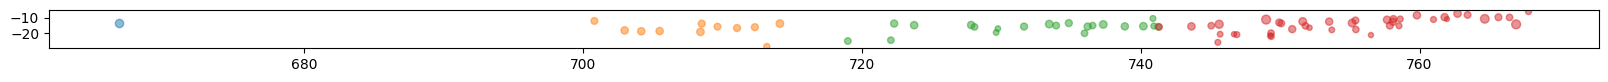

In [33]:
# now write the dict to a json file
import json

fps = 10
skipped = 3
y0 = 160
U_camera = 15 # mm/s

fig, ax = plt.subplots(figsize=(20, 0.5))
all_X, all_Y, all_R = [], [], []

for f in frames_to_process:
    frame_id = f[-8:-4]
    time = 3 * int(frame_id) / fps

    # extract info
    if frame_id not in bubble_dict:
        print(f"Warning: no bubbles detected for frame {frame_id}")
        continue
    item = bubble_dict[frame_id]
    cx = [bubble[0] for bubble in item]
    cy = [bubble[1] for bubble in item]
    rad = [bubble[2] for bubble in item]

    # convert to world coordinates
    XWorld, YWorld, RWorld = pix_to_world(cx, cy, rad)

    # convert to global coordinates (accounting for camera movement)
    y_start = y0 + U_camera * time
    YWorld += y_start

    # write to output
    all_X.extend(XWorld)
    all_Y.extend(YWorld)
    all_R.extend(RWorld)


    ax.scatter(YWorld, XWorld, s=RWorld*100, alpha=0.5, label=f"Frame {frame_id}")



In [34]:
os.makedirs("out", exist_ok=True)
data = np.column_stack([all_X, all_Y, all_R])

# raise warning if to be written file already exists and do not overwrite without confirmation!
output_file = f"out/bubbles_{test_no:02d}.csv"
if os.path.exists(output_file):
    warnings.warn(f"File {output_file} already exists and will be overwritten.")

else:
    np.savetxt(output_file, data, delimiter=",", header="X_world,Y_world,R_world", comments="")
    print(f"saved {len(data)} bubbles → {output_file}")


saved 74 bubbles → out/bubbles_10.csv
